# CCO09: Notch Maturation

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc

In [2]:
WORK_DIR = "/home/herbert/PyProjects/cocultured_organ/workspace/CCO09"

In [3]:
os.system(f"mkdir -p {WORK_DIR}")

0

# 1. Preprocess - done in CCO08

In [7]:
os.system(f"mkdir -p {WORK_DIR}/adata")

0

In [8]:
os.system(f"ln -s {WORK_DIR}/../CCO08/adata/new_data/raw {WORK_DIR}/adata")
os.system(f"ln -s {WORK_DIR}/../CCO08/adata/new_data/processed {WORK_DIR}/adata")

0

# 2. Cell type annotation

## 2.1 label

In [14]:
os.system(f"mkdir -p {WORK_DIR}/adata/celltype_annotated")

0

In [4]:
adata = sc.read_h5ad(f"{WORK_DIR}/adata/processed/ALL.h5ad")

In [6]:
group_names = ["ALL", "VO-C", "VO-G8", "VasHO-C", "VasHO-G8"]

celltypes_dict = {
    '0':  'MU', 
    '1':  'CM',
    '2':  'MU',
    '3':  'MU',
    '4':  'MU',
    '5':  'MU',
    '6':  'MU',
    '7':  'EC',
    '8':  'EC',
    '9':  'CM',
    '10': 'MU',
    '11': 'MU',
    '12': 'MU',
    '13': 'EP',
    '14': 'EP',
    '15': 'CM',
    '16': 'CM',
    '17': 'MU',
    '18': 'CM',
}

In [10]:
adata.obs['cell_type'] = adata.obs['leiden'].map(celltypes_dict)
adata.obs['cell_type'] = adata.obs['cell_type'].astype("category")

In [15]:
adata.write(f"{WORK_DIR}/adata/celltype_annotated/ALL.h5ad")
for batch in adata.obs["batch"].unique():
    adata[adata.obs["batch"] == batch].write(f"{WORK_DIR}/adata/celltype_annotated/{batch}.h5ad")

## 2.2 visualization

In [4]:
adata = sc.read_h5ad(f"{WORK_DIR}/adata/celltype_annotated/ALL.h5ad")

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


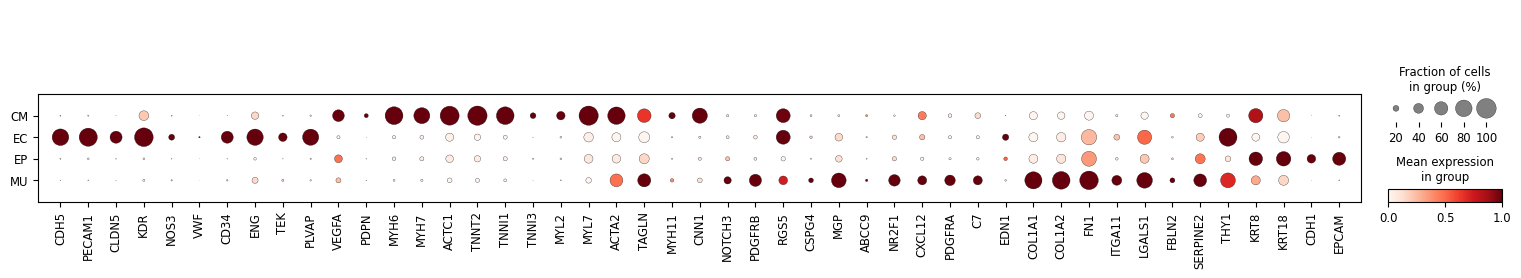

In [5]:
marker_dict = [
    "CDH5", "PECAM1", "CLDN5", "KDR", "NOS3", "VWF", "CD34", "ENG", "TEK", "PLVAP",
    "VEGFA", "PDPN", "MYH6", "MYH7", "ACTC1", "TNNT2", "TNNI1", "TNNI3", "MYL2", "MYL7",
    "ACTA2", "TAGLN", "MYH11", "CNN1", "NOTCH3", "PDGFRB", "RGS5", "CSPG4", "MGP", "ABCC9",
    "NR2F1", "CXCL12", "PDGFRA", "C7", "EDN1", "COL1A1", "COL1A2", "FN1", "ITGA11", "LGALS1",
    "FBLN2", "SERPINE2", "THY1", "KRT8", "KRT18", "CDH1", "EPCAM"
]

sc.pl.dotplot(adata, 
              marker_dict, 
              groupby="cell_type", 
              standard_scale="var", 
              show=True)

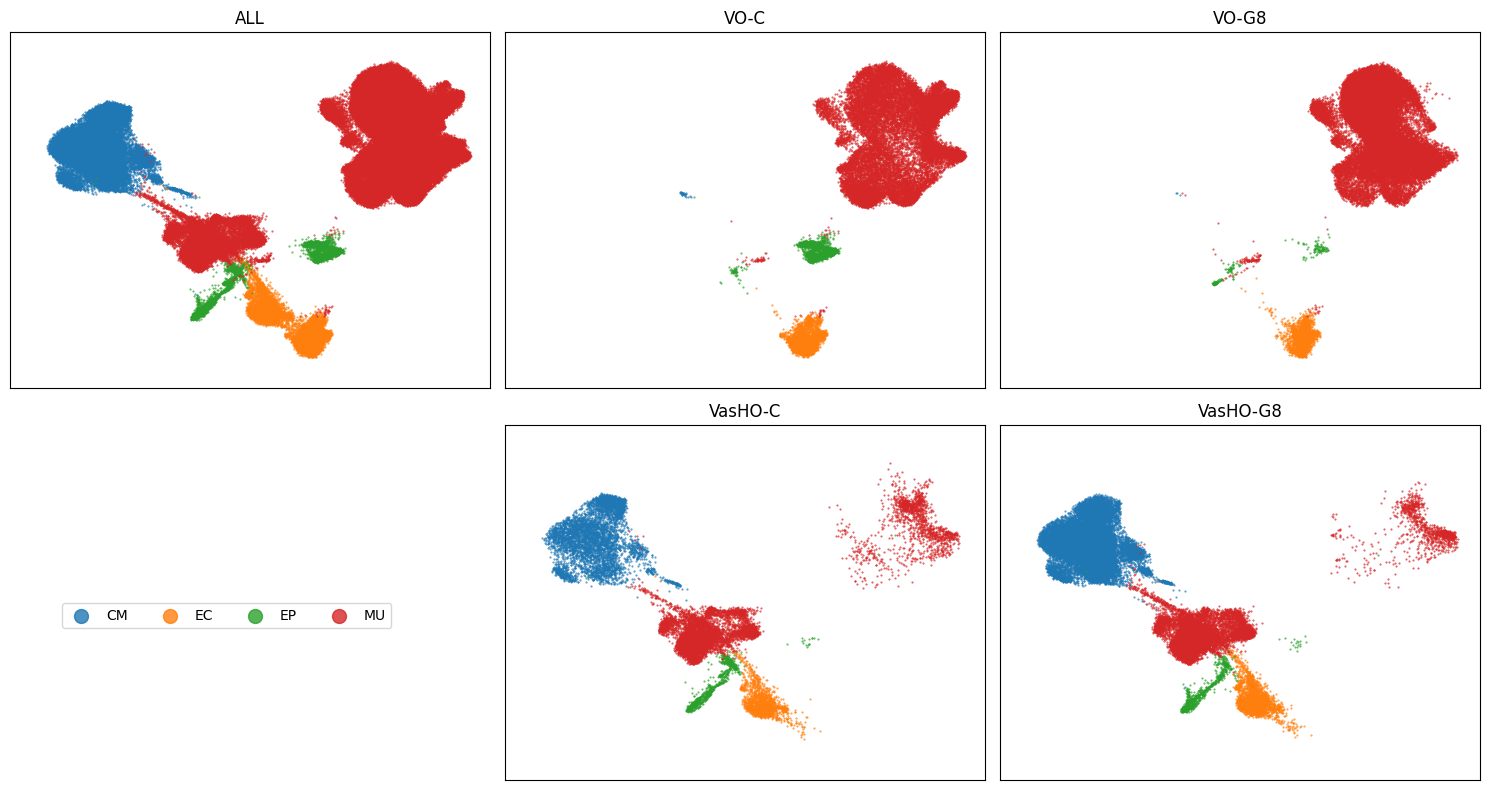

In [6]:
groups = ("ALL", "VO-C", "VO-G8", "VasHO-C", "VasHO-G8")

tab20_rgb = [(r, g, b, 0.8) for r, g, b in plt.cm.tab10.colors]

fig, axs = plt.subplots(2, 3, figsize=(15,8))
axs = axs.flatten()
axs_new = [axs[0], axs[1], axs[2], axs[4], axs[5]]
fig.delaxes(axs[3])

handles = []
labels = []


xmin = -9
xmax = 19
ymin = -8
ymax = 18

for i, group in enumerate(groups):
    ax = axs_new[i]
    if group == "ALL":
        adata_sub = adata
    else:
        adata_sub = adata[adata.obs["batch"] == group]

    for j, ct in enumerate(adata.obs["cell_type"].unique().sort_values()):
        sc_plot = ax.scatter(
            adata_sub[adata_sub.obs["cell_type"] == ct].obsm["X_umap"][:,0],
            adata_sub[adata_sub.obs["cell_type"] == ct].obsm["X_umap"][:,1],
            s=0.25,
            label=ct,
            color=tab20_rgb[j]
        )
        if i == 0:
            handles.append(sc_plot)
            labels.append(ct)
    
    ax.set_title(group)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_xticks([])
    ax.set_yticks([])

fig.legend(
    handles, labels,
    loc='lower left',
    ncol=5,
    markerscale=20,
    bbox_to_anchor=(0.04, 0.2)
)

plt.tight_layout()
plt.show()

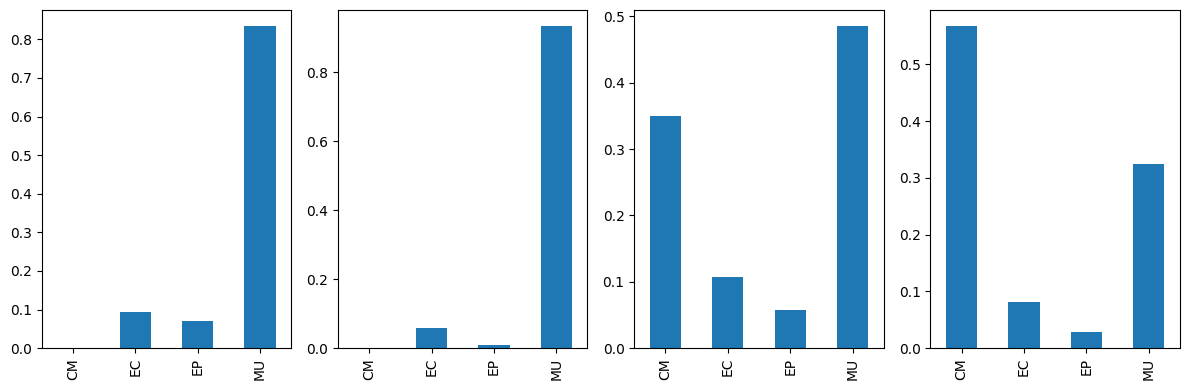

In [7]:
fig, axs = plt.subplots(1, 4, figsize=(12, 4))

for i, batch in enumerate(adata.obs["batch"].unique().sort_values()):
    adata_sub = adata[adata.obs["batch"] == batch]
    ser = adata_sub.obs["cell_type"].value_counts().sort_index()
    ser = ser / ser.sum()
    ser.plot.bar(ax=axs[i])

plt.tight_layout()
plt.show()

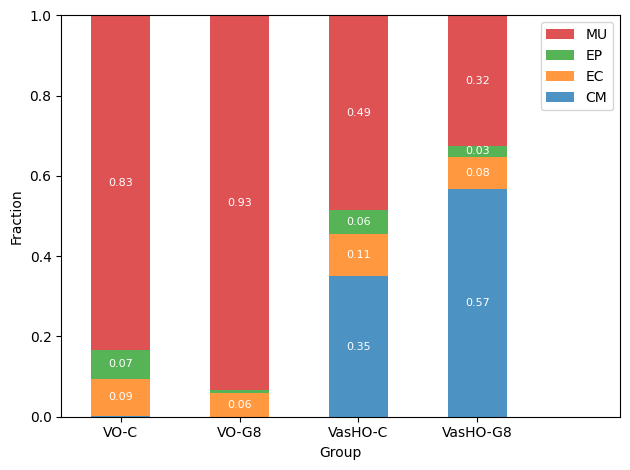

In [14]:
res = []
res_col = []

for j, sample in enumerate(groups):    
    if sample == 'ALL':
        continue
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        res.append(adata_sample.obs['cell_type'].value_counts().sort_index())
        res_col.append(sample)
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df = np.divide(df, df.sum())
df = df.T

ax = df.plot(kind='bar', stacked=True, color=[tab20_rgb[i] for i, col in enumerate(df.columns)])
plt.xlabel('Group')
plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 4.2))
plt.xticks(rotation=0)
# plt.title(f"{ct} cluster distribution")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1])

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.01:
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='white'
            )

plt.tight_layout()
plt.show()